<a href="https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/UAP_Milikan_Koreksi_Chunningham.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9
})

l    = 6.00e-3        # Jarak antar pelat kapasitor (m)
d    = 1.00e-3        # Jarak satu skala grid (m)
rho_o = 875.0         # Massa jenis minyak parafin (kg/m³)
rho_f = 1.29          # Massa jenis udara (kg/m³)
eta   = 1.85e-5       # Viskositas udara (N·s/m²)
g     = 9.81          # Percepatan gravitasi (m/s²)
p     = 101325.0      # Tekanan udara standar (Pa)
T_C   = 25.0          # Suhu laboratorium (°C)
T_K   = T_C + 273.15  # Suhu dalam Kelvin
T_ref = 296.0         # Suhu referensi Cunningham (K)
b_ref = 8.2e-3        # Konstanta Cunningham referensi (Pa·m)
e_lit = 1.602e-19     # Nilai literatur muatan elementer (C)
delta_rho = rho_o - rho_f  # Selisih massa jenis (kg/m³)

data_raw = {
    'No'  : list(range(1, 21)),
    'd_m' : [1e-3] * 20,   # Jarak tempuh (m)
    'td_s': [15.42, 15.38, 22.10, 22.15, 11.05, 11.10, 11.08,
              9.50,  9.55, 18.20, 18.25, 13.40, 13.35, 25.60,
             25.55, 10.20, 10.15, 10.22, 16.80, 16.75],
    'Ur_V': [500, 500, 500, 500, 400, 400, 400,
              450, 450, 500, 500, 400, 400, 550,
              550, 450, 450, 450, 500, 500],
    'tu_s': [8.21,  3.45, 10.15,  4.12, 12.50,  5.10,  3.20,
              9.80,  4.30,  7.15,  3.10, 15.20,  6.40,  8.40,
              3.50, 11.10,  4.80,  3.10,  6.50,  2.90],
    'Us_V': [310, 154, 240, 121, 380, 192, 128,
              410, 205, 280, 139, 365, 184, 180,
               91, 430, 214, 144, 255, 128]
}

df = pd.DataFrame(data_raw)
df.set_index('No', inplace=True)

In [53]:
df['vd'] = df['d_m'] / df['td_s']   # m/s
df['vu'] = df['d_m'] / df['tu_s']   # m/s

df['r_stokes'] = np.sqrt((9 * eta * df['vd']) / (2 * g * delta_rho))  # m
df['qf_nc'] = (18 * np.pi * eta * l * df['vd'] / df['Us_V']) * \
              np.sqrt((eta * df['vd']) / (2 * g * delta_rho))
df['qr_nc'] = (18 * np.pi * eta * l * (df['vd'] + df['vu']) / df['Ur_V']) * \
              np.sqrt((eta * df['vd']) / (2 * g * delta_rho))
df['qavg_nc'] = (df['qf_nc'] + df['qr_nc']) / 2

scale = 1e19

b_T = b_ref * (T_K / T_ref)
b_over_p = b_T / p  # satuan meter

print(f'Konstanta Cunningham:')
print(f'   b(T)  = {b_ref:.1e} × ({T_K}/{T_ref}) = {b_T:.4e} Pa·m')
print(f'   b/p   = {b_T:.4e} / {p} = {b_over_p:.4e} m')

r_S2 = df['r_stokes']**2   # r_Stokes²
df['rc'] = 0.5 * (-b_over_p + np.sqrt(b_over_p**2 + 4 * r_S2))
df['Cc'] = 1 + b_T / (p * df['rc'])
df['qf_cc'] = (6 * np.pi * eta * l * df['vd']) / (df['Us_V'] * df['Cc']) * df['rc']
df['qr_cc'] = (6 * np.pi * eta * l * (df['vd'] + df['vu'])) / (df['Ur_V'] * df['Cc']) * df['rc']
df['qavg_cc'] = (df['qf_cc'] + df['qr_cc']) / 2

print('\nHasil Koreksi dan Muatan Terkoreksi:')
display(df)

Konstanta Cunningham:
   b(T)  = 8.2e-03 × (298.15/296.0) = 8.2596e-03 Pa·m
   b/p   = 8.2596e-03 / 101325.0 = 8.1516e-08 m

Hasil Koreksi dan Muatan Terkoreksi:


,d_m,td_s,Ur_V,tu_s,Us_V,vd,vu,r_stokes,qf_nc,qr_nc,qavg_nc,rc,Cc,qf_cc,qr_cc,qavg_cc
No,,,,,,,,,,,,,,,,
1,0.001,15.42,500,8.21,310,0.000065,0.000122,7.936550e-07,3.473840e-19,6.199006e-19,4.836423e-19,7.539431e-07,1.108119,2.978038e-19,5.314256e-19,4.146147e-19
2,0.001,15.38,500,3.45,154,0.000065,0.000290,7.946864e-07,7.020093e-19,1.180116e-18,9.410627e-19,7.549732e-07,1.107971,6.019356e-19,1.011887e-18,8.069112e-19
3,0.001,22.10,500,10.15,240,0.000045,0.000099,6.629455e-07,2.615161e-19,3.988442e-19,3.301802e-19,6.234394e-07,1.130751,2.174942e-19,3.317055e-19,2.745999e-19
4,0.001,22.15,500,4.12,121,0.000045,0.000243,6.621968e-07,5.169542e-19,7.976830e-19,6.573186e-19,6.226922e-07,1.130908,4.298442e-19,6.632684e-19,5.465563e-19
5,0.001,11.05,400,12.50,380,0.000090,0.000080,9.375465e-07,4.671658e-19,8.361334e-19,6.516496e-19,8.976743e-07,1.090807,4.100614e-19,7.339279e-19,5.719947e-19
6,0.001,11.10,400,5.10,192,0.000090,0.000196,9.354325e-07,9.183588e-19,1.400227e-18,1.159293e-18,8.955623e-07,1.091022,8.058651e-19,1.228707e-18,1.017286e-18
7,0.001,11.08,400,3.20,128,0.000090,0.000313,9.362764e-07,1.381270e-18,1.972453e-18,1.676861e-18,8.964054e-07,1.090936,1.212215e-18,1.731043e-18,1.471629e-18
8,0.001,9.50,450,9.80,410,0.000105,0.000102,1.011142e-06,5.431613e-19,9.746112e-19,7.588862e-19,9.712054e-07,1.083932,4.813107e-19,8.636308e-19,6.724708e-19
9,0.001,9.55,450,4.30,205,0.000105,0.000233,1.008492e-06,1.077802e-18,1.581473e-18,1.329638e-18,9.685571e-07,1.084162,9.547683e-19,1.400944e-18,1.177856e-18


In [54]:
def pairwise_diff(q_array):
    """Hitung selisih mutlak semua pasangan unik (segitiga atas)."""
    n = len(q_array)
    diffs = []
    for i in range(n):
        for j in range(i+1, n):
            diffs.append(abs(q_array[i] - q_array[j]))
    return np.array(diffs)

q_nc = df['qavg_nc'].values
q_cc = df['qavg_cc'].values

diffs_nc = pairwise_diff(q_nc) * scale   # dalam 10^-19 C
diffs_cc = pairwise_diff(q_cc) * scale

print(f'Jumlah kombinasi selisih unik: {len(diffs_nc)} (dari 20 tetesan: C(20,2) = 190)')
print(f'\nSelisih Min/Max (Tanpa Koreksi): {diffs_nc.min():.4f} – {diffs_nc.max():.4f} ×10⁻¹⁹ C')
print(f'Selisih Min/Max (Cunningham)   : {diffs_cc.min():.4f} – {diffs_cc.max():.4f} ×10⁻¹⁹ C')

Jumlah kombinasi selisih unik: 190 (dari 20 tetesan: C(20,2) = 190)

Selisih Min/Max (Tanpa Koreksi): 0.0108 – 13.5178 ×10⁻¹⁹ C
Selisih Min/Max (Cunningham)   : 0.0652 – 12.0503 ×10⁻¹⁹ C


In [55]:
def fit_gaussian_peak(diffs, x_lo=1.0, x_hi=2.5, bins=60):
    """
    Fit Gaussian pada puncak pertama (isolasi 1e).
    Returns: mu, sigma, ehist (mean kurva), n_peak, se
    """
    peak_data = diffs[(diffs >= x_lo) & (diffs <= x_hi)]
    mu, sigma = norm.fit(peak_data)
    n_peak = len(peak_data)
    se = sigma / np.sqrt(n_peak)
    return mu, sigma, n_peak, se, peak_data

x_lo, x_hi = 1.0, 2.5

mu_nc, sig_nc, n_nc, se_nc, peak_nc = fit_gaussian_peak(diffs_nc, x_lo, x_hi)
mu_cc, sig_cc, n_cc, se_cc, peak_cc = fit_gaussian_peak(diffs_cc, x_lo, x_hi)

print('Hasil Fit Gaussian pada Puncak Pertama (Area Isolasi 1e):')
print(f"\n{'Parameter':<30} {'Tanpa Koreksi':>16} {'Cunningham':>16}")
print('-'*64)
print(f"{'μ (ehist) (×10⁻¹⁹ C)':<30} {mu_nc:>16.3f} {mu_cc:>16.3f}")
print(f"{'σ (×10⁻¹⁹ C)':<30} {sig_nc:>16.3f} {sig_cc:>16.3f}")
print(f"{'n data di puncak':<30} {n_nc:>16d} {n_cc:>16d}")
print(f"{'SE (×10⁻¹⁹ C)':<30} {se_nc:>16.3f} {se_cc:>16.3f}")
print(f"{'Error vs literatur (%)':<30} {abs(mu_nc-e_lit*scale)/(e_lit*scale)*100:>15.2f}% {abs(mu_cc-e_lit*scale)/(e_lit*scale)*100:>15.2f}%")

Hasil Fit Gaussian pada Puncak Pertama (Area Isolasi 1e):

Parameter                         Tanpa Koreksi       Cunningham
----------------------------------------------------------------
μ (ehist) (×10⁻¹⁹ C)                      1.716            1.639
σ (×10⁻¹⁹ C)                              0.391            0.381
n data di puncak                             47               47
SE (×10⁻¹⁹ C)                             0.057            0.056
Error vs literatur (%)                    7.13%            2.29%


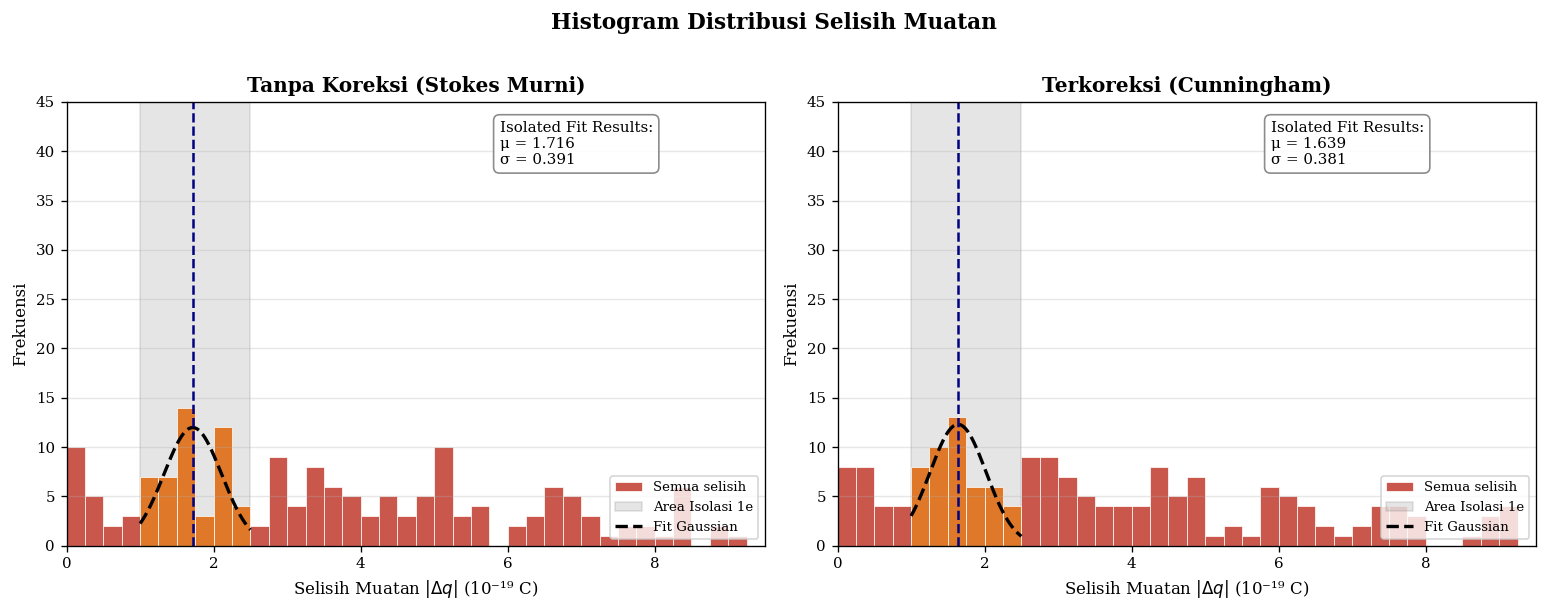

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
bins_all = np.arange(0, 9.5, 0.25)

datasets = [
    (diffs_nc, peak_nc, mu_nc, sig_nc, 'Tanpa Koreksi (Stokes Murni)', axes[0]),
    (diffs_cc, peak_cc, mu_cc, sig_cc, 'Terkoreksi (Cunningham)',       axes[1])
]

for diffs, peak_data, mu, sig, title, ax in datasets:
    n_hist, bins_out, patches = ax.hist(
        diffs, bins=bins_all, color='#c0392b', edgecolor='white',
        linewidth=0.5, alpha=0.85, label='Semua selisih'
    )

    ax.axvspan(x_lo, x_hi, color='gray', alpha=0.20, label=f'Area Isolasi 1e')

    ax.hist(
        peak_data, bins=bins_all, color='#e67e22', edgecolor='white',
        linewidth=0.5, alpha=0.85
    )

    x_fit = np.linspace(x_lo, x_hi, 300)
    bin_width = bins_all[1] - bins_all[0]
    y_fit = norm.pdf(x_fit, mu, sig) * len(peak_data) * bin_width
    ax.plot(x_fit, y_fit, 'k--', linewidth=2.0, label='Fit Gaussian')

    ax.axvline(mu, color='navy', linestyle='--', linewidth=1.5)

    ax.text(0.62, 0.86,
            f'Isolated Fit Results:\nμ = {mu:.3f}\nσ = {sig:.3f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.9))

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(r'Selisih Muatan $|\Delta q|$ (10⁻¹⁹ C)', fontsize=10)
    ax.set_ylabel('Frekuensi', fontsize=10)
    ax.set_xlim(0, 9.5)
    ax.set_ylim(0, 45)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Histogram Distribusi Selisih Muatan', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('histogram_PDA.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
e_hist_nc = mu_nc * 1e-19   # dalam Coulomb
e_hist_cc = mu_cc * 1e-19

df['n_nc']   = np.round(df['qavg_nc'] / e_hist_nc).astype(int)
df['eest_nc'] = df['qavg_nc'] / df['n_nc']   # estimasi e tiap tetesan

df['n_cc']   = np.round(df['qavg_cc'] / e_hist_cc).astype(int)
df['eest_cc'] = df['qavg_cc'] / df['n_cc']

print('Tabel. Tanpa Koreksi (×10⁻¹⁹ C):')
tbl6 = pd.DataFrame({
    'qr': df['qr_nc']*scale,
    'qf': df['qf_nc']*scale,
    'qavg': df['qavg_nc']*scale,
    'n' : df['n_nc'],
    'eest': df['eest_nc']*scale
}).round(3)
tbl6.index.name = 'No'
display(tbl6)

print('\nKoreksi Cunningham (×10⁻¹⁹ C):')
tbl7 = pd.DataFrame({
    'qr': df['qr_cc']*scale,
    'qf': df['qf_cc']*scale,
    'qavg': df['qavg_cc']*scale,
    'n' : df['n_cc'],
    'eest': df['eest_cc']*scale
}).round(3)
tbl7.index.name = 'No'
display(tbl7)

Tabel. Tanpa Koreksi (×10⁻¹⁹ C):


,qr,qf,qavg,n,eest
No,,,,,
1,6.199,3.474,4.836,3,1.612
2,11.801,7.020,9.411,5,1.882
3,3.988,2.615,3.302,2,1.651
4,7.977,5.170,6.573,4,1.643
5,8.361,4.672,6.516,4,1.629
6,14.002,9.184,11.593,7,1.656
7,19.725,13.813,16.769,10,1.677
8,9.746,5.432,7.589,4,1.897
9,15.815,10.778,13.296,8,1.662



Koreksi Cunningham (×10⁻¹⁹ C):


,qr,qf,qavg,n,eest
No,,,,,
1,5.314,2.978,4.146,3,1.382
2,10.119,6.019,8.069,5,1.614
3,3.317,2.175,2.746,2,1.373
4,6.633,4.298,5.466,3,1.822
5,7.339,4.101,5.720,3,1.907
6,12.287,8.059,10.173,6,1.695
7,17.310,12.122,14.716,9,1.635
8,8.636,4.813,6.725,4,1.681
9,14.009,9.548,11.779,7,1.683


In [58]:
def linear_fit(n_vals, q_vals):
    """Regresi linear + ralat gradien (Sm)."""
    slope, intercept, r_val, p_val, se_slope = linregress(n_vals, q_vals)
    return slope, intercept, r_val**2, se_slope

n_nc_arr = df['n_nc'].values.astype(float)
q_nc_arr = df['qavg_nc'].values * scale   # ×10⁻¹⁹ C

m_nc, c_nc, R2_nc, Sm_nc = linear_fit(n_nc_arr, q_nc_arr)

n_cc_arr = df['n_cc'].values.astype(float)
q_cc_arr = df['qavg_cc'].values * scale

m_cc, c_cc, R2_cc, Sm_cc = linear_fit(n_cc_arr, q_cc_arr)

print(f"\n{'Parameter':<35} {'Tanpa Koreksi':>16} {'Cunningham':>16}")
print('-'*68)
print(f"{'e_regr (slope m) ×10⁻¹⁹ C':<35} {m_nc:>16.3f} {m_cc:>16.3f}")
print(f"{'Ralat gradien Sm ×10⁻¹⁹ C':<35} {Sm_nc:>16.3f} {Sm_cc:>16.3f}")
print(f"{'Intercept c ×10⁻¹⁹ C':<35} {c_nc:>16.4f} {c_cc:>16.4f}")
print(f"{'R²':<35} {R2_nc:>16.4f} {R2_cc:>16.4f}")
print(f"{'Error vs literatur (%)':<35} {abs(m_nc-e_lit*scale)/(e_lit*scale)*100:>15.2f}% {abs(m_cc-e_lit*scale)/(e_lit*scale)*100:>15.2f}%")

print(f'\ne_regr (Tanpa Koreksi) = ({m_nc:.3f} ± {Sm_nc:.3f}) ×10⁻¹⁹ C')
print(f'e_regr (Cunningham)    = ({m_cc:.3f} ± {Sm_cc:.3f}) ×10⁻¹⁹ C')


Parameter                              Tanpa Koreksi       Cunningham
--------------------------------------------------------------------
e_regr (slope m) ×10⁻¹⁹ C                      1.669            1.664
Ralat gradien Sm ×10⁻¹⁹ C                      0.038            0.059
Intercept c ×10⁻¹⁹ C                          0.0790          -0.1791
R²                                            0.9909           0.9776
Error vs literatur (%)                         4.21%            3.86%

e_regr (Tanpa Koreksi) = (1.669 ± 0.038) ×10⁻¹⁹ C
e_regr (Cunningham)    = (1.664 ± 0.059) ×10⁻¹⁹ C


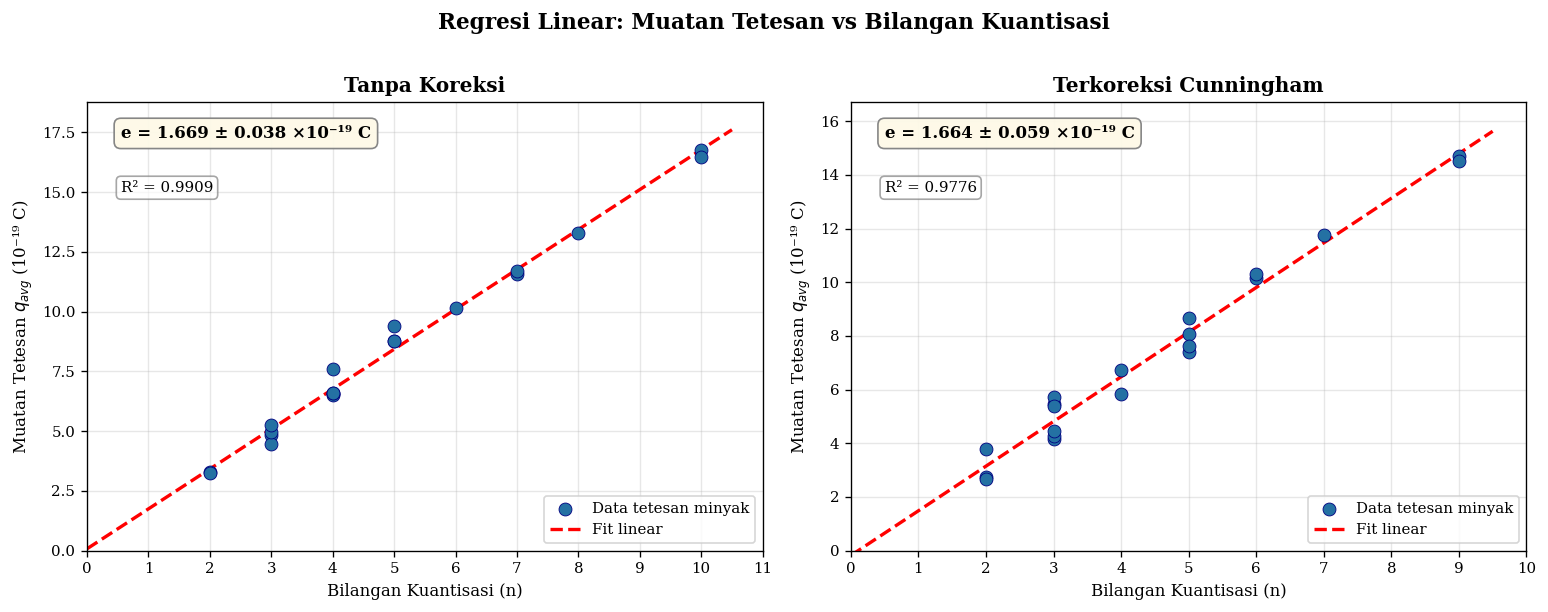

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_data = [
    (n_nc_arr, q_nc_arr, m_nc, c_nc, R2_nc, Sm_nc, 'Tanpa Koreksi', axes[0]),
    (n_cc_arr, q_cc_arr, m_cc, c_cc, R2_cc, Sm_cc, 'Terkoreksi Cunningham', axes[1])
]

for n_arr, q_arr, m, c, R2, Sm, title, ax in plot_data:
    ax.scatter(n_arr, q_arr, color='#2471a3', s=60, zorder=5,
               label='Data tetesan minyak', edgecolors='navy', linewidths=0.5)

    x_line = np.array([0, max(n_arr) + 0.5])
    y_line = m * x_line + c
    ax.plot(x_line, y_line, 'r--', linewidth=2.0, label='Fit linear')

    ax.text(0.05, 0.92,
            f'e = {m:.3f} ± {Sm:.3f} ×10⁻¹⁹ C',
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#fef9e7', edgecolor='gray', alpha=0.95))

    ax.text(0.05, 0.80,
            f'R² = {R2:.4f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.7))

    ax.set_xlim(0, max(n_arr) + 1)
    ax.set_ylim(0, max(q_arr) + 2)
    ax.set_xlabel('Bilangan Kuantisasi (n)', fontsize=10)
    ax.set_ylabel(r'Muatan Tetesan $q_{avg}$ (10⁻¹⁹ C)', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xticks(range(0, int(max(n_arr)) + 2))

plt.suptitle('Regresi Linear: Muatan Tetesan vs Bilangan Kuantisasi',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('regresi_linear.png', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
print(f'Nilai literatur:  e = 1.602 × 10⁻¹⁹ C')
print()

results = [
    ('ehist  (Tanpa Koreksi)', mu_nc, se_nc,
     abs(mu_nc - e_lit*scale)/(e_lit*scale)*100),
    ('eregr  (Tanpa Koreksi)', m_nc, Sm_nc,
     abs(m_nc  - e_lit*scale)/(e_lit*scale)*100),
    ('ehist  (Cunningham)',    mu_cc, se_cc,
     abs(mu_cc - e_lit*scale)/(e_lit*scale)*100),
    ('eregr  (Cunningham)',    m_cc, Sm_cc,
     abs(m_cc  - e_lit*scale)/(e_lit*scale)*100),
]

print(f"{'Metode':<28} {'Nilai (×10⁻¹⁹ C)':>22} {'Error (%)':>10}")
print('-' * 65)
for name, val, err, pct in results:
    print(f"{name:<28} ({val:.3f} ± {err:.3f}) × 10⁻¹⁹ C  {pct:>8.2f}%")


Nilai literatur:  e = 1.602 × 10⁻¹⁹ C

Metode                             Nilai (×10⁻¹⁹ C)  Error (%)
-----------------------------------------------------------------
ehist  (Tanpa Koreksi)       (1.716 ± 0.057) × 10⁻¹⁹ C      7.13%
eregr  (Tanpa Koreksi)       (1.669 ± 0.038) × 10⁻¹⁹ C      4.21%
ehist  (Cunningham)          (1.639 ± 0.056) × 10⁻¹⁹ C      2.29%
eregr  (Cunningham)          (1.664 ± 0.059) × 10⁻¹⁹ C      3.86%
